In [ ]:
dummy_data = {
    "images": [
        # Vertical patterns
        [
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0]
        ],

        [
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0]
        ],

        [
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0]
        ],

        # Horizontal patterns
        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ],

        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ],

        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ]
    ],

    "labels": [0, 0, 0, 1, 1, 1]
}

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [5]:
(X_train,_),(X_test,_) = tf.keras.datasets.mnist.load_data()

In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

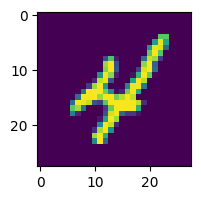

In [ ]:
import matplotlib.pyplot as plt

X_train_img = X_train[:10]

plt.figure(figsize=(10,2))
for i in range(10):
    plt.imshow(X_train_img[i])

plt.show()

In [ ]:
from tensorflow.keras import layers
latend_dim=2
#encdor
encoder_input = keras.Input(shape=(28,28,1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(128, activation='relu')(x)

z_mean = layers.Dense(latend_dim, name='z_mean')(x)
z_log_var = layers.Dense(latend_dim, name='z_log_var')(x)


In [27]:
def sampling(args):
    z_mean,z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)))
    z = z_mean + tf.exp(0.5*z_log_var) * epsilon 

    return z
z = layers.Lambda(sampling)([z_mean,z_log_var])

In [22]:
#decoder
decoder_input = keras.Input(shape=(latend_dim,))
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(28*28, activation='sigmoid')(x)
decoder_output = layers.Reshape((28,28,1))(x)
decoder = keras.Model(decoder_input,decoder_output, name='decoder')



In [23]:
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_2 (Dense)             (None, 128)               384       
                                                                 
 dense_3 (Dense)             (None, 784)               101136    
                                                                 
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
Total params: 101,520
Trainable params: 101,520
Non-trainable params: 0
_________________________________________________________________
